In [1]:
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display, Latex, Markdown

import plot_opts, utils
plt.rcParams.update(plot_opts.params)

In [2]:
resolution = 0.02
mode = "galvanostatic"
name_of_study = "cylinders"
mesh_folder = f"output/{name_of_study}/20-20-80/{resolution}/{mode}"
figures_dir = os.path.join('figures', *mesh_folder.split("/")[1:])
utils.make_dir_if_missing(figures_dir)
n_procs = 2
global_figures_dir = os.path.join("figures", "current_distribution")
utils.make_dir_if_missing(global_figures_dir)

In [3]:
def get_input_dir(Wa, Kr, gamma, n_procs=n_procs, alpha=1e5):
    return os.path.join(mesh_folder, f'butler_volmer/0.001-{Wa}-{Kr}/1.0C/1-1-4/{gamma}-{alpha}/{n_procs}')

def read_data(files_list):
    results = []
    for results_file_json in files_list:
        if os.path.isfile(results_file_json):
            with open(results_file_json, "r") as fp:
                results_row = json.load(fp)
                if results_row.get("i (stdev) se/am [A/m2]") is not None:
                    results.append(results_row)
        else:
            results.append({"I left [A]": np.nan, "I interface [A]": np.nan, "I right [A]": np.nan,
                                "I (target) right [A]": np.nan, "I_interface error (potential) [A]": np.nan,
                            "I interface (electrolyte potential) [A]": np.nan, "I interface (active material potential) [A]": np.nan})
    return results

In [4]:
vary_res_files_deg_1 = [
    "output/cylinders/20-20-80/0.01/galvanostatic/butler_volmer/0.001-0.01-0.01/1.0C/1-1-4/0.01/16/simulation.json",
    "output/cylinders/20-20-80/0.0075/galvanostatic/butler_volmer/0.001-0.01-0.01/1.0C/1-1-4/0.01/16/simulation.json",
    "output/cylinders/20-20-80/0.005/galvanostatic/butler_volmer/0.001-0.01-0.01/1.0C/1-1-4/0.01/32/simulation.json",
    "output/cylinders/20-20-80/0.00375/galvanostatic/butler_volmer/0.001-0.01-0.01/1.0C/1-1-4/0.01/64/simulation.json",
    "output/cylinders/20-20-80/0.0025/galvanostatic/butler_volmer/0.001-0.01-0.01/1.0C/1-1-4/0.01/32/simulation.json",
    
]
vary_res_files_deg_2 = [
    "output/cylinders/20-20-80/0.01/galvanostatic/butler_volmer/0.001-0.01-0.01/1.0C/2-2-4/0.01/16/simulation.json",
     "output/cylinders/20-20-80/0.0075/galvanostatic/butler_volmer/0.001-0.01-0.01/1.0C/2-2-4/0.01/16/simulation.json",
    "output/cylinders/20-20-80/0.005/galvanostatic/butler_volmer/0.001-0.01-0.01/1.0C/2-2-4/0.01/64/simulation.json",
    "output/cylinders/20-20-80/0.00375/galvanostatic/butler_volmer/0.001-0.01-0.01/1.0C/2-2-4/0.01/64/simulation.json",
    "output/cylinders/20-20-80/0.0025/galvanostatic/butler_volmer/0.001-0.01-0.01/1.0C/2-2-4/0.01/32/simulation.json",
    
]
resolution = [0.01, 0.0075, 0.005, 0.00375, 0.0025]
res_data1 = pd.DataFrame(read_data(vary_res_files_deg_1))
res_data2 = pd.DataFrame(read_data(vary_res_files_deg_2))
res_data2[["I left [A]", "I interface [A]", "I right [A]", "I (target) right [A]", "I_interface error (potential) [A]"]]

,I left [A],I interface [A],I right [A],I (target) right [A],I_interface error (potential) [A]
0,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN


m1: nan, c1: nan
m2: nan, c2: nan


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


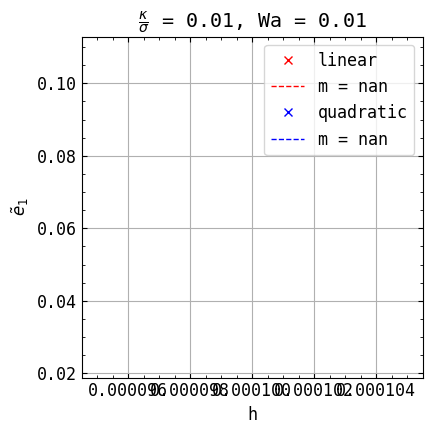

In [5]:
fig, ax = plt.subplots()
error1 =  list(np.abs(res_data1["I_interface error (potential) [A]"]/res_data1["I interface [A]"]))
error2 =  list(np.abs(res_data2["I_interface error (potential) [A]"]/res_data2["I interface [A]"]))
m1 = (error1[-1] - error1[0])/(resolution[-1] - resolution[0])
c1 = error1[0] - m1 * resolution[0]
m2 = (error2[2] - error2[0])/(resolution[2] - resolution[0])
c2 = error2[0] - m2 * resolution[0]
print(f"m1: {m1:.1f}, c1: {c1:.2f}")
print(f"m2: {m2:.1f}, c2: {c2:.2f}")
ax.plot(resolution, error1, 'rx', label='linear')
ax.plot([resolution[0], 1e-4], [error1[0], 0.10859], 'r--', label=f'm = {m1:.1f}')
ax.plot(resolution, error2, 'bx', label='quadratic')
ax.plot([1e-4, resolution[0]], [0.02314, error2[0]], 'b--', label=f'm = {m2:.1f}')
ax.set_ylabel(r'$\tilde{e}_1$')
ax.set_xlabel('h')
# ax.set_xlim([1e-4, 1e-2])
# ax.set_ylim([0, 1])
ax.set_title(r"$\frac{\kappa}{\sigma}$ = 0.01, Wa = 0.01")
# ax.axhline(y=0.1, linestyle='--', color='black')
ax.set_box_aspect(1)
ax.grid()
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(global_figures_dir, "local-error.eps"), format="eps")

m1: nan, c1: nan
m2: nan, c2: nan


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


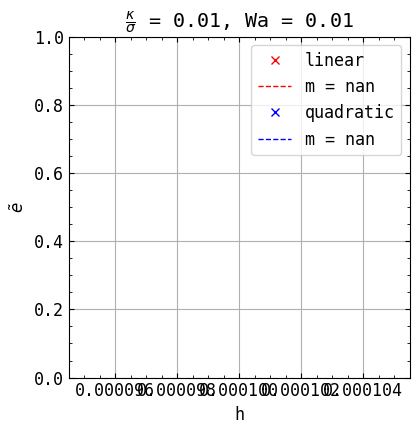

In [6]:
fig, ax = plt.subplots()
error1 =  list(np.abs((res_data1["I interface (electrolyte potential) [A]"] + res_data1["I interface (active material potential) [A]"])/res_data1["I interface [A]"]))
error2 =  list(np.abs((res_data2["I interface (electrolyte potential) [A]"] + res_data2["I interface (active material potential) [A]"])/res_data2["I interface [A]"]))
m1 = (error1[-1] - error1[0])/(resolution[-1] - resolution[0])
c1 = error1[0] - m1 * resolution[0]
m2 = (error2[2] - error2[0])/(resolution[2] - resolution[0])
c2 = error2[0] - m2 * resolution[0]
print(f"m1: {m1:.1f}, c1: {c1:.2f}")
print(f"m2: {m2:.1f}, c2: {c2:.2f}")
ax.plot(resolution, error1, 'rx', label='linear')
ax.plot([resolution[0], 1e-4], [error1[0], 0.10859], 'r--', label=f'm = {m1:.1f}')
ax.plot(resolution, error2, 'bx', label='quadratic')
ax.plot([1e-4, resolution[0]], [0.02314, error2[0]], 'b--', label=f'm = {m2:.1f}')
ax.set_ylabel(r'$\tilde{e}$')
ax.set_xlabel('h')
# ax.set_xlim([1e-4, 1e-2])
ax.set_ylim([0, 1])
# ax.axhline(y=0.05, linestyle='-.', color='black')
ax.set_box_aspect(1)
ax.grid()
ax.legend()
ax.set_title(r"$\frac{\kappa}{\sigma}$ = 0.01, Wa = 0.01")
plt.tight_layout()
plt.savefig(os.path.join(global_figures_dir, "global-error.eps"), format="eps")

In [7]:
results = []
Wa_test = [0.01, 0.1, 1.0, 10.0, 100.0]
Kr_test = [0.01, 1.0, 100.0]
for Wa in Wa_test:
    for Kr in Kr_test:
        results_file_json = os.path.join(get_input_dir(Wa, Kr, gamma=1e-06, alpha=1e5), "simulation.json")
        if not os.path.isfile(results_file_json):
            results_file_json = os.path.join(get_input_dir(Wa, Kr, gamma=0.0001), "simulation.json")
        if os.path.isfile(results_file_json):
            with open(results_file_json, "r") as fp:
                results_row = json.load(fp)
                if results_row.get("i (stdev) se/am [A/m2]") is not None:
                    results.append(results_row)
        else:
            print(f"{results_file_json} not found")
data = pd.DataFrame(results)

In [8]:
# Normalized stdev of current density at SE/AM interface
df_left = data[['Positive Wa', 'Kr', 'i (avg) left [A/m2]', 'i (stdev) left [A/m2]']]
df_se_am = data[['Positive Wa', 'Kr', 'i (avg) se/am [A/m2]', 'i (stdev) se/am [A/m2]', 'i (avg) right [A/m2]']]
df_right = data[['Positive Wa', 'Kr', 'i (avg) right [A/m2]', 'i (stdev) right [A/m2]']]

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


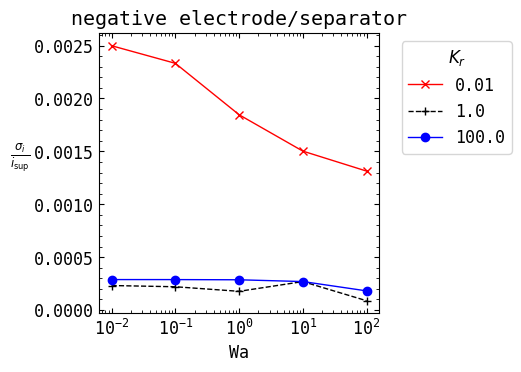

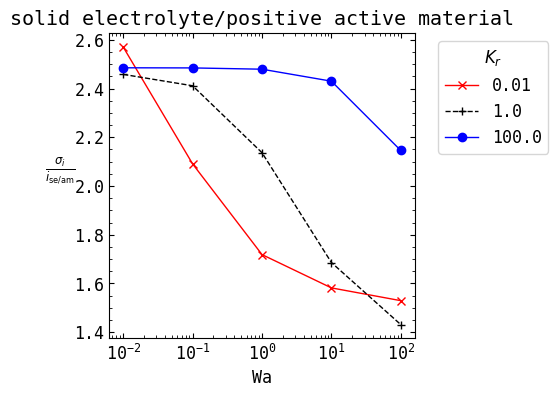

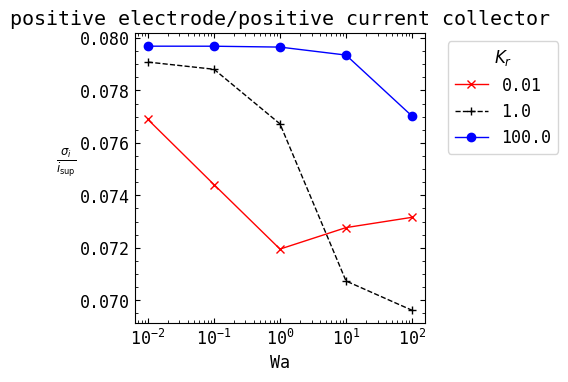

In [9]:
fig, ax = plt.subplots()
styles = ['rx-', 'k+--', 'bo-', 'y*-', 'bx--', 'k*--', 'r+--', 'bx--', 'y+--']
for idx, Kr in enumerate(Kr_test):
    df_left_ = df_left[np.isclose(df_left['Kr'], Kr)]
    ax.semilogx(df_left_['Positive Wa'], df_left_['i (stdev) left [A/m2]'] / np.abs(df_left_['i (avg) left [A/m2]']), styles[idx], label=f'{Kr}')
ax.set_box_aspect(1)
ax.set_ylabel(r'$\frac{\sigma_{i}}{i_{\mathrm{sup}}}$', rotation=0, labelpad=10)
ax.set_xlabel('Wa')
# ax.set_ylim([0, 1e-3])
ax.set_title('negative electrode/separator')
ax.legend(title='$K_r$', bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'i_stdev_norm_left_by_wa'), format='eps')

fig, ax = plt.subplots()
for idx, Kr in enumerate(Kr_test):
    df_se_am_ = df_se_am[np.isclose(df_se_am['Kr'], Kr)]
    ax.plot(df_se_am_['Positive Wa'], df_se_am_['i (stdev) se/am [A/m2]'] / np.abs(df_se_am_['i (avg) se/am [A/m2]']), styles[idx], label=f'{Kr}')
ax.set_box_aspect(1)
# ax.set_ylabel(r'$\frac{\sigma_{i_n}}{\mu_{i_n}}$', rotation=0, labelpad=10)
ax.set_ylabel(r'$\frac{\sigma_{i}}{i_{\mathrm{se/am}}}$', rotation=0, labelpad=10)
ax.set_xlabel('Wa')
ax.set_xscale('log')
# ax.set_yscale('log')
# ax.set_ylim([0, 5e-3])
ax.set_title('solid electrolyte/positive active material')
ax.legend(title='$K_r$', bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'i_stdev_norm_se_am_by_wa.eps'), format='eps')

fig, ax = plt.subplots()
for idx, Kr in enumerate(Kr_test):
    df_right_ = df_right[np.isclose(df_right['Kr'], Kr)]
    ax.semilogx(df_right_['Positive Wa'], df_right_['i (stdev) right [A/m2]'] / np.abs(df_right_['i (avg) right [A/m2]']), styles[idx], label=f'{Kr}')
ax.set_box_aspect(1)
# ax.set_ylabel(r'$\frac{\sigma_{i_n}}{\mu_{i_n}}$', rotation=0, labelpad=10)
ax.set_ylabel(r'$\frac{\sigma_{i}}{i_{\mathrm{sup}}}$', rotation=0, labelpad=10)
ax.set_xlabel('Wa')
ax.set_title('positive electrode/positive current collector')
ax.legend(title='$K_r$', bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'i_stdev_norm_right_by_wa.eps'), format='eps')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


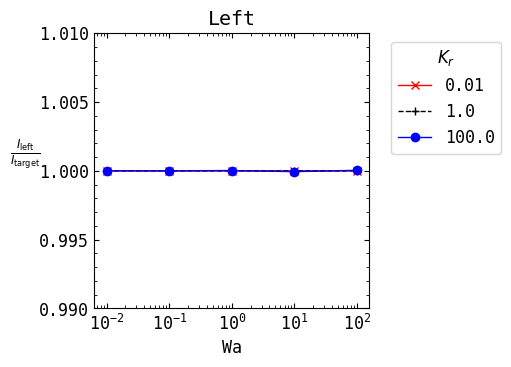

In [10]:
df_0 = data[['Positive Wa', 'Kr', 'I left [A]', 'I (target) right [A]']]
fig, ax = plt.subplots()
for idx, Kr in enumerate(Kr_test):
    df_0_ = df_0[np.isclose(df_0['Kr'], Kr)]
    ax.semilogx(df_0_['Positive Wa'], np.abs(df_0_['I left [A]'] / df_0_['I (target) right [A]']), styles[idx], label=f'{Kr}')
ax.set_box_aspect(1)
ax.set_ylim([0.99, 1.01])
ax.set_ylabel(r'$\frac{I_{\mathrm{left}}}{I_{\mathrm{target}}}$', rotation=0, labelpad=10)
ax.set_xlabel('Wa')
ax.legend(title='$K_r$', bbox_to_anchor=(1.05, 1.0), loc='upper left')
ax.set_title('Left')
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'i_error_left_by_wa.eps'), format='eps')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


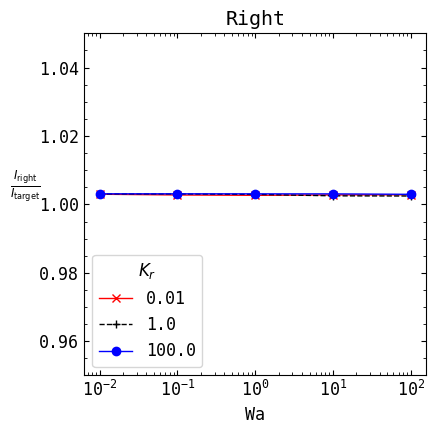

In [11]:
df_2 = data[['Positive Wa', 'Kr', 'I right [A]', 'I (target) right [A]']]
fig, ax = plt.subplots()
for idx, Kr in enumerate(Kr_test):
    df_2_ = df_2[np.isclose(df_2['Kr'], Kr)]
    ax.semilogx(df_2_['Positive Wa'], np.abs(df_2_['I right [A]'] / df_2_['I (target) right [A]']), styles[idx], label=f'{Kr}')
ax.set_box_aspect(1)
# ax.axhline(y=0.95, color='gray', linestyle='--')
# ax.axhline(y=1.05, color='gray', linestyle='--')
ax.set_ylim([0.95, 1.05])
ax.set_ylabel(r'$\frac{I_{\mathrm{right}}}{I_{\mathrm{target}}}$', rotation=0, labelpad=10)
ax.set_xlabel('Wa')
ax.legend(title='$K_r$', loc='lower left')
ax.set_title("Right")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'i_error_right_by_wa.eps'), format='eps')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


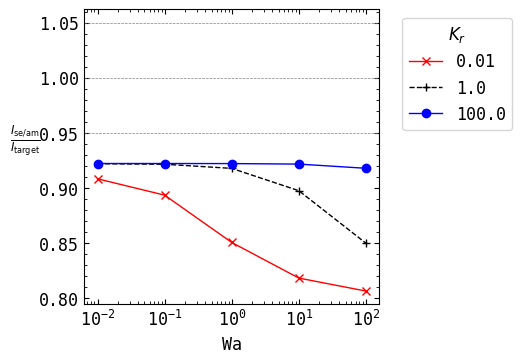

In [12]:
df_1 = data[['Positive Wa', 'Kr', 'I interface [A]', 'I (target) right [A]']]
fig, ax = plt.subplots()
for idx, Kr in enumerate(Kr_test):
    df_1_ = df_1[np.isclose(df_1['Kr'], Kr)]
    ax.semilogx(df_1_['Positive Wa'], np.abs(df_1_['I interface [A]'] / df_1_['I (target) right [A]']), styles[idx], label=f'{Kr}')
ax.axhline(y=0.95, color='gray', linestyle='--', linewidth=0.5)
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.5)
ax.axhline(y=1.05, color='gray', linestyle='--', linewidth=0.5)
ax.set_box_aspect(1)
ax.set_ylabel(r'$\frac{I_{\mathrm{se/am}}}{I_{\mathrm{target}}}$', rotation=0, labelpad=10)
ax.set_xlabel('Wa')
ax.legend(title='$K_r$', bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'i_error_se_am_by_wa.eps'), format='eps')

## Normalized interface error is given by

## $$\tilde{e}=\frac{\int_{\Gamma_X}\vert {\kappa^{(1)} \nabla \phi^{(1)}\cdot\mathbf{n}^{(1)}-\kappa^{(2)}\nabla\phi^{(2)}\cdot\mathbf{n}^{(2)}} \vert\mathrm{dS}}{I_{cell}}$$

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


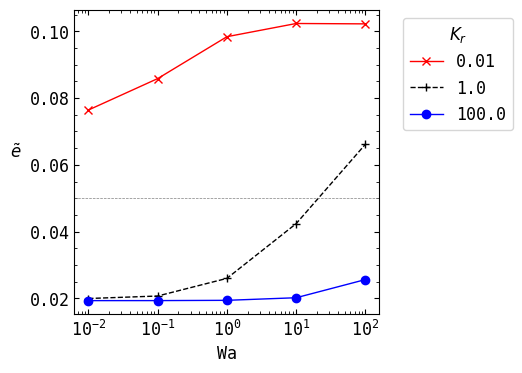

In [13]:
display(Markdown("""## Normalized interface error is given by"""))
display(Markdown(r"""## $$\tilde{e}=\frac{\int_{\Gamma_X}\vert {\kappa^{(1)} \nabla \phi^{(1)}\cdot\mathbf{n}^{(1)}-\kappa^{(2)}\nabla\phi^{(2)}\cdot\mathbf{n}^{(2)}} \vert\mathrm{dS}}{I_{cell}}$$"""))
df_1 = data[['Positive Wa', 'Kr', 'I interface [A]', 'I (target) right [A]', 'I_interface error (potential) [A]']]
fig, ax = plt.subplots()
for idx, Kr in enumerate(Kr_test):
    # if not np.isclose(Kr, 1.0):
    #     continue
    # if Kr < 0.1:
    #     continue
    df_1_ = df_1[np.isclose(df_1['Kr'], Kr)]
    ax.semilogx(df_1_['Positive Wa'], np.abs(df_1_['I_interface error (potential) [A]'] / df_1_['I (target) right [A]']), styles[idx], label=f'{Kr}')
# ax.axhline(y=0.95, color='gray', linestyle='--', linewidth=0.5)
# ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.5)
ax.axhline(y=0.05, color='gray', linestyle='--', linewidth=0.5)
# ax.set_ylim([0, 2.05])
ax.set_box_aspect(1)
ax.set_ylabel(r'$\tilde{e}$', rotation=0, labelpad=10)
ax.set_xlabel('Wa')
ax.legend(title='$K_r$', bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'ix_error_se_am_by_wa.eps'), format='eps')

## Normalized interface error norm is given by 

## $\tilde{e}=\frac{\Vert {\kappa^{(1)} \nabla \phi^{(1)}\cdot\mathbf{n}^{(1)}-\kappa^{(2)}\nabla\phi^{(2)}\cdot\mathbf{n}^{(2)}}\Vert_{\Gamma_X}}{\Vert{\kappa^{(1)}\nabla\phi^{(1)}\cdot\mathbf{n}^{(1)}}\Vert_{\Gamma_X}} $

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


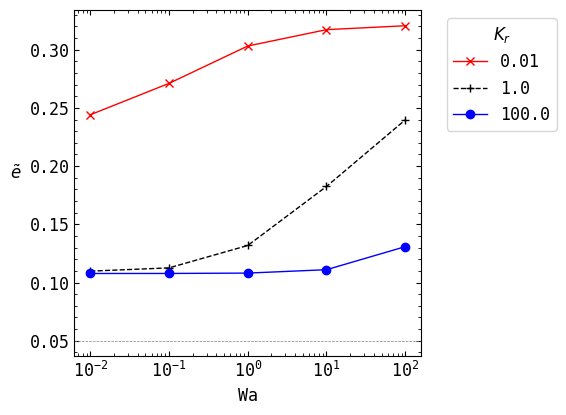

In [14]:
display(Markdown("## Normalized interface error norm is given by "))
display(Markdown(r"## $\tilde{e}=\frac{\Vert {\kappa^{(1)} \nabla \phi^{(1)}\cdot\mathbf{n}^{(1)}-\kappa^{(2)}\nabla\phi^{(2)}\cdot\mathbf{n}^{(2)}}\Vert_{\Gamma_X}}{\Vert{\kappa^{(1)}\nabla\phi^{(1)}\cdot\mathbf{n}^{(1)}}\Vert_{\Gamma_X}} $"))
df_1 = data[['Positive Wa', 'Kr', 'I interface [A]', 'I (target) right [A]', 'I_interface error norm (normalized)']]
fig, ax = plt.subplots()
for idx, Kr in enumerate(Kr_test):
    # if Kr < 0.1:
    #     continue
    df_1_ = df_1[np.isclose(df_1['Kr'], Kr)]
    ax.semilogx(df_1_['Positive Wa'], df_1_['I_interface error norm (normalized)'], styles[idx], label=f'{Kr}')
# ax.axhline(y=0.95, color='gray', linestyle='--', linewidth=0.5)
# ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.5)
ax.axhline(y=0.05, color='gray', linestyle='--', linewidth=0.5)
# ax.set_ylim([0, 2.05])
ax.set_box_aspect(1)
ax.set_ylabel(r'$\tilde{e}$', rotation=0, labelpad=10)
ax.set_xlabel('Wa')
ax.legend(title='$K_r$', bbox_to_anchor=(1.05, 1.0), loc='upper left')
# ax.set_title()
# plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'ix2_error_se_am_by_wa.eps'), format='eps')

## Normalized $\sigma_i$ and $\tilde{e}$ evolution without additional penalty

In [15]:
results = []
Wa_test = [0.01, 0.1, 1.0, 10.0, 100.0]
Kr_test = [0.01, 1.0, 100.0]
for Wa in Wa_test:
    for Kr in Kr_test:
        results_file_json = os.path.join(get_input_dir(Wa, Kr, gamma=1e-06, alpha=0.0), "simulation.json")
        # if not os.path.isfile(results_file_json):
        #     results_file_json = os.path.join(get_input_dir(Wa, Kr, gamma=0.0001), "simulation.json")
        if os.path.isfile(results_file_json):
            with open(results_file_json, "r") as fp:
                results_row = json.load(fp)
                if results_row.get("i (stdev) se/am [A/m2]") is not None:
                    results.append(results_row)
        else:
            print(f"{results_file_json} not found")
data = pd.DataFrame(results)

output/cylinders/20-20-80/0.02/galvanostatic/butler_volmer/0.001-10.0-0.01/1.0C/1-1-4/1e-06-0.0/2/simulation.json not found
output/cylinders/20-20-80/0.02/galvanostatic/butler_volmer/0.001-10.0-100.0/1.0C/1-1-4/1e-06-0.0/2/simulation.json not found
output/cylinders/20-20-80/0.02/galvanostatic/butler_volmer/0.001-100.0-0.01/1.0C/1-1-4/1e-06-0.0/2/simulation.json not found
output/cylinders/20-20-80/0.02/galvanostatic/butler_volmer/0.001-100.0-1.0/1.0C/1-1-4/1e-06-0.0/2/simulation.json not found
output/cylinders/20-20-80/0.02/galvanostatic/butler_volmer/0.001-100.0-100.0/1.0C/1-1-4/1e-06-0.0/2/simulation.json not found


In [16]:
# Normalized stdev of current density at SE/AM interface
df_left = data[['Positive Wa', 'Kr', 'i (avg) left [A/m2]', 'i (stdev) left [A/m2]']]
df_se_am = data[['Positive Wa', 'Kr', 'i (avg) se/am [A/m2]', 'i (stdev) se/am [A/m2]', 'i (avg) right [A/m2]']]
df_right = data[['Positive Wa', 'Kr', 'i (avg) right [A/m2]', 'i (stdev) right [A/m2]']]

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


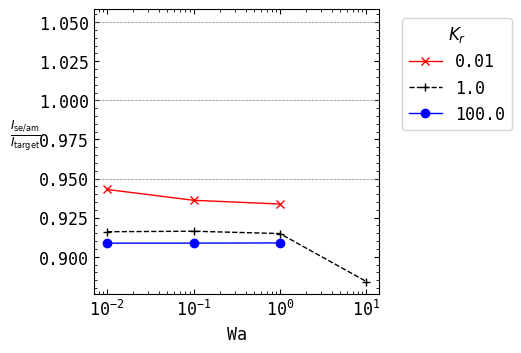

In [17]:
df_1 = data[['Positive Wa', 'Kr', 'I interface [A]', 'I (target) right [A]']]
fig, ax = plt.subplots()
for idx, Kr in enumerate(Kr_test):
    df_1_ = df_1[np.isclose(df_1['Kr'], Kr)]
    ax.semilogx(df_1_['Positive Wa'], np.abs(df_1_['I interface [A]'] / df_1_['I (target) right [A]']), styles[idx], label=f'{Kr}')
ax.axhline(y=0.95, color='gray', linestyle='--', linewidth=0.5)
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.5)
ax.axhline(y=1.05, color='gray', linestyle='--', linewidth=0.5)
ax.set_box_aspect(1)
ax.set_ylabel(r'$\frac{I_{\mathrm{se/am}}}{I_{\mathrm{target}}}$', rotation=0, labelpad=10)
ax.set_xlabel('Wa')
ax.legend(title='$K_r$', bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'i_error_se_am_by_wa.eps'), format='eps')

## Normalized interface error is given by

## $$\tilde{e}=\frac{\int_{\Gamma_X}\vert {\kappa^{(1)} \nabla \phi^{(1)}\cdot\mathbf{n}^{(1)}-\kappa^{(2)}\nabla\phi^{(2)}\cdot\mathbf{n}^{(2)}} \vert\mathrm{dS}}{I_{cell}}$$

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


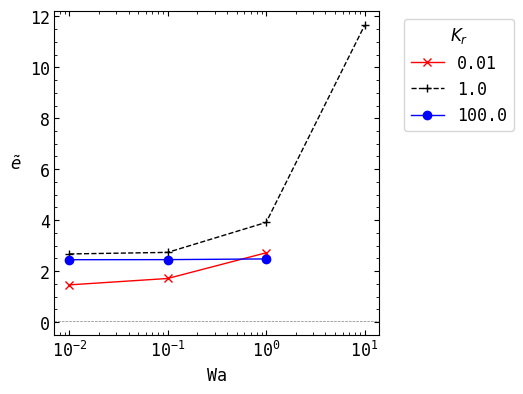

In [18]:
display(Markdown("""## Normalized interface error is given by"""))
display(Markdown(r"""## $$\tilde{e}=\frac{\int_{\Gamma_X}\vert {\kappa^{(1)} \nabla \phi^{(1)}\cdot\mathbf{n}^{(1)}-\kappa^{(2)}\nabla\phi^{(2)}\cdot\mathbf{n}^{(2)}} \vert\mathrm{dS}}{I_{cell}}$$"""))
df_1 = data[['Positive Wa', 'Kr', 'I interface [A]', 'I (target) right [A]', 'I_interface error (potential) [A]']]
fig, ax = plt.subplots()
for idx, Kr in enumerate(Kr_test):
    # if not np.isclose(Kr, 1.0):
    #     continue
    # if Kr < 0.1:
    #     continue
    df_1_ = df_1[np.isclose(df_1['Kr'], Kr)]
    ax.semilogx(df_1_['Positive Wa'], np.abs(df_1_['I_interface error (potential) [A]'] / df_1_['I (target) right [A]']), styles[idx], label=f'{Kr}')
# ax.axhline(y=0.95, color='gray', linestyle='--', linewidth=0.5)
# ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.5)
ax.axhline(y=0.05, color='gray', linestyle='--', linewidth=0.5)
# ax.set_ylim([0, 2.05])
ax.set_box_aspect(1)
ax.set_ylabel(r'$\tilde{e}$', rotation=0, labelpad=10)
ax.set_xlabel('Wa')
ax.legend(title='$K_r$', bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'ix_error_se_am_by_wa.eps'), format='eps')

## Normalized interface error norm is given by 

## $\tilde{e}=\frac{\Vert {\kappa^{(1)} \nabla \phi^{(1)}\cdot\mathbf{n}^{(1)}-\kappa^{(2)}\nabla\phi^{(2)}\cdot\mathbf{n}^{(2)}}\Vert_{\Gamma_X}}{\Vert{\kappa^{(1)}\nabla\phi^{(1)}\cdot\mathbf{n}^{(1)}}\Vert_{\Gamma_X}} $

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


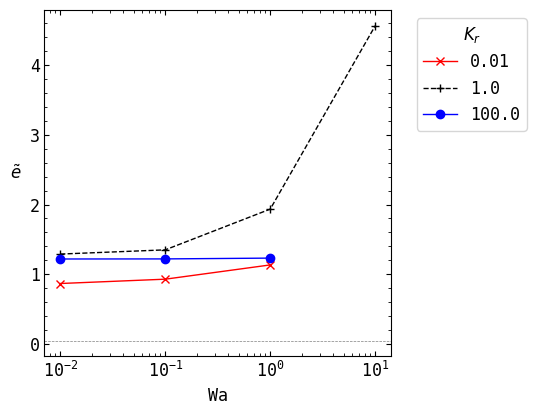

In [19]:
display(Markdown("## Normalized interface error norm is given by "))
display(Markdown(r"## $\tilde{e}=\frac{\Vert {\kappa^{(1)} \nabla \phi^{(1)}\cdot\mathbf{n}^{(1)}-\kappa^{(2)}\nabla\phi^{(2)}\cdot\mathbf{n}^{(2)}}\Vert_{\Gamma_X}}{\Vert{\kappa^{(1)}\nabla\phi^{(1)}\cdot\mathbf{n}^{(1)}}\Vert_{\Gamma_X}} $"))
df_1 = data[['Positive Wa', 'Kr', 'I interface [A]', 'I (target) right [A]', 'I_interface error norm (normalized)']]
fig, ax = plt.subplots()
for idx, Kr in enumerate(Kr_test):
    # if Kr < 0.1:
    #     continue
    df_1_ = df_1[np.isclose(df_1['Kr'], Kr)]
    ax.semilogx(df_1_['Positive Wa'], df_1_['I_interface error norm (normalized)'], styles[idx], label=f'{Kr}')
# ax.axhline(y=0.95, color='gray', linestyle='--', linewidth=0.5)
# ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.5)
ax.axhline(y=0.05, color='gray', linestyle='--', linewidth=0.5)
# ax.set_ylim([0, 2.05])
ax.set_box_aspect(1)
ax.set_ylabel(r'$\tilde{e}$', rotation=0, labelpad=10)
ax.set_xlabel('Wa')
ax.legend(title='$K_r$', bbox_to_anchor=(1.05, 1.0), loc='upper left')
# ax.set_title()
# plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'ix2_error_se_am_by_wa.eps'), format='eps')